# 📈 Week 1 — Equity Market Analysis (v2)
### Nifty Stock Price Data · Returns · Volatility · Macro Overlays

**Author:** Kishore | Motilal Oswal SIP 2026  
**Tools:** Python · yfinance · pandas · matplotlib · seaborn

---

### What's improved in v2:
- **5 years of data** for all statistical calculations (Sharpe, Volatility, Drawdown)
- **Charts show only last 1 year** — clean and readable
- **Annual returns table** — breaks down performance year by year across market regimes
- **RBI rate overlay** on banking stocks
- **USD/INR overlay** on IT stocks with currency-adjusted returns

> *"Metrics calculated on 5Y data; all charts show last 1Y for interpretability"*

---
## 🔧 Section 0 — Install & Import Libraries

In [1]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## 📌 Section 1 — Define Stock Universe

In [2]:
STOCKS = {
    'HDFC Bank':  'HDFCBANK.NS',
    'Reliance':   'RELIANCE.NS',
    'Infosys':    'INFY.NS',
    'TCS':        'TCS.NS',
    'ICICI Bank': 'ICICIBANK.NS'
}

PERIOD_STATS  = '5y'    # For all calculations
PERIOD_CHART  = '1y'    # For all charts — keeps visuals clean
BENCHMARK     = '^NSEI'
TRADING_DAYS  = 252

tickers = list(STOCKS.values())
names   = list(STOCKS.keys())
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
stock_color = dict(zip(names, colors))

print(f'Stock universe : {names}')
print(f'Stats period   : {PERIOD_STATS} (for Sharpe, Volatility, Drawdown)')
print(f'Chart period   : {PERIOD_CHART} (for all plots)')

Stock universe : ['HDFC Bank', 'Reliance', 'Infosys', 'TCS', 'ICICI Bank']
Stats period   : 5y (for Sharpe, Volatility, Drawdown)
Chart period   : 1y (for all plots)


---
## 📥 Section 2 — Download Price Data (5Y for stats, slice 1Y for charts)

In [3]:
print('Downloading 5Y stock data from Yahoo Finance...')

raw = yf.download(tickers + [BENCHMARK], period=PERIOD_STATS, auto_adjust=True, progress=False)

# ── Full 5Y data (for all calculations) ───────────────────────────────────────
close_5y   = raw['Close'][tickers].copy()
close_5y.columns = names
close_5y.dropna(how='all', inplace=True)

volume_5y  = raw['Volume'][tickers].copy()
volume_5y.columns = names

nifty_5y   = raw['Close'][BENCHMARK].dropna()

# ── Last 1Y slice (for all charts) ───────────────────────────────────────────
close_1y   = close_5y.last('365D')
nifty_1y   = nifty_5y.last('365D')

# Normalised versions for plotting
norm_1y    = (close_1y / close_1y.iloc[0]) * 100
nifty_norm_1y = (nifty_1y / nifty_1y.iloc[0]) * 100

print(f'\n✅ 5Y data: {len(close_5y)} trading days  ({close_5y.index[0].date()} → {close_5y.index[-1].date()})')
print(f'   1Y chart window: {close_1y.index[0].date()} → {close_1y.index[-1].date()}')
print()
print('Latest closing prices (₹):')
print(close_5y.iloc[-1].apply(lambda x: f'₹{x:,.2f}'))


✅ 5Y data: 1237 trading days  (2021-05-06 → 2026-05-06)
   1Y chart window: 2025-05-07 → 2026-05-06

Latest closing prices (₹):
HDFC Bank       ₹779.85
Reliance      ₹1,434.30
Infosys       ₹1,168.00
TCS           ₹2,423.50
ICICI Bank    ₹1,258.40
Name: 2026-05-06 00:00:00, dtype: object


---
## 📊 Section 3 — Price Trend Chart (1Y window)

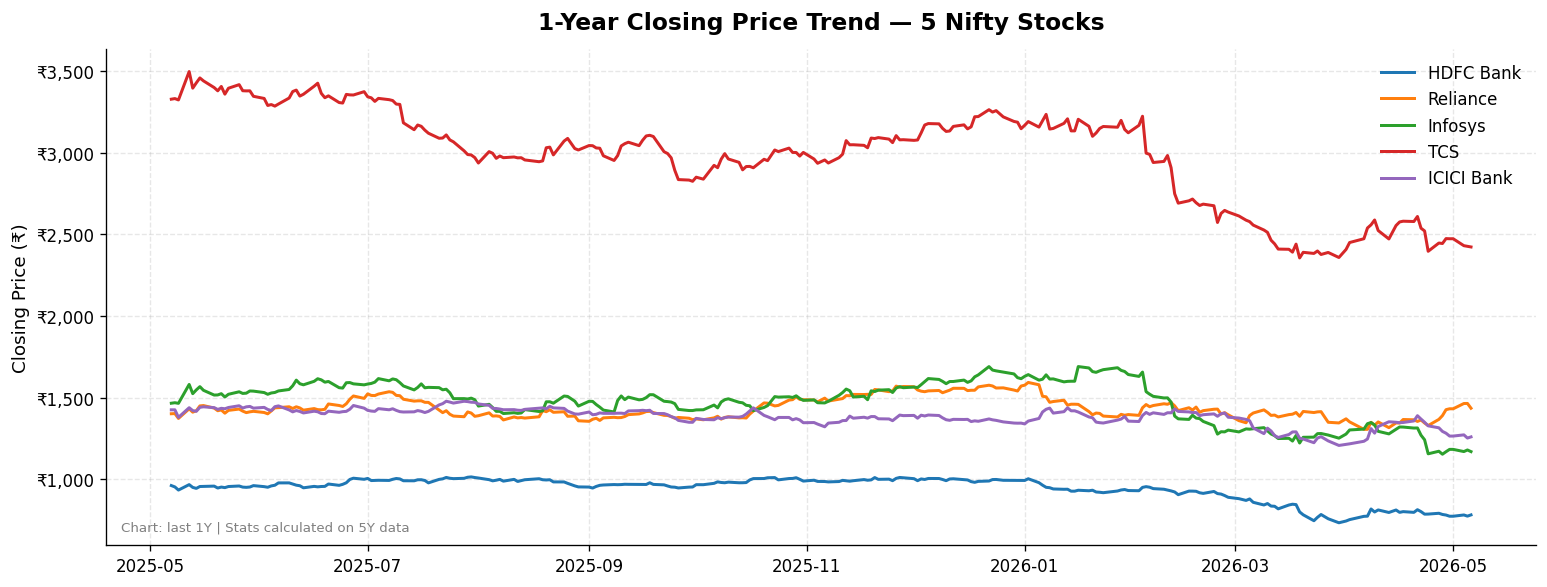

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

for stock in names:
    ax.plot(close_1y.index, close_1y[stock], label=stock,
            color=stock_color[stock], linewidth=1.8)

ax.set_title('1-Year Closing Price Trend — 5 Nifty Stocks', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Closing Price (₹)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(frameon=False, fontsize=10)
ax.annotate('Chart: last 1Y | Stats calculated on 5Y data',
            xy=(0.01, 0.03), xycoords='axes fraction', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('price_trend.png', bbox_inches='tight')
plt.show()

---
## 📈 Section 4 — Normalised Performance vs Nifty 50 (1Y chart)

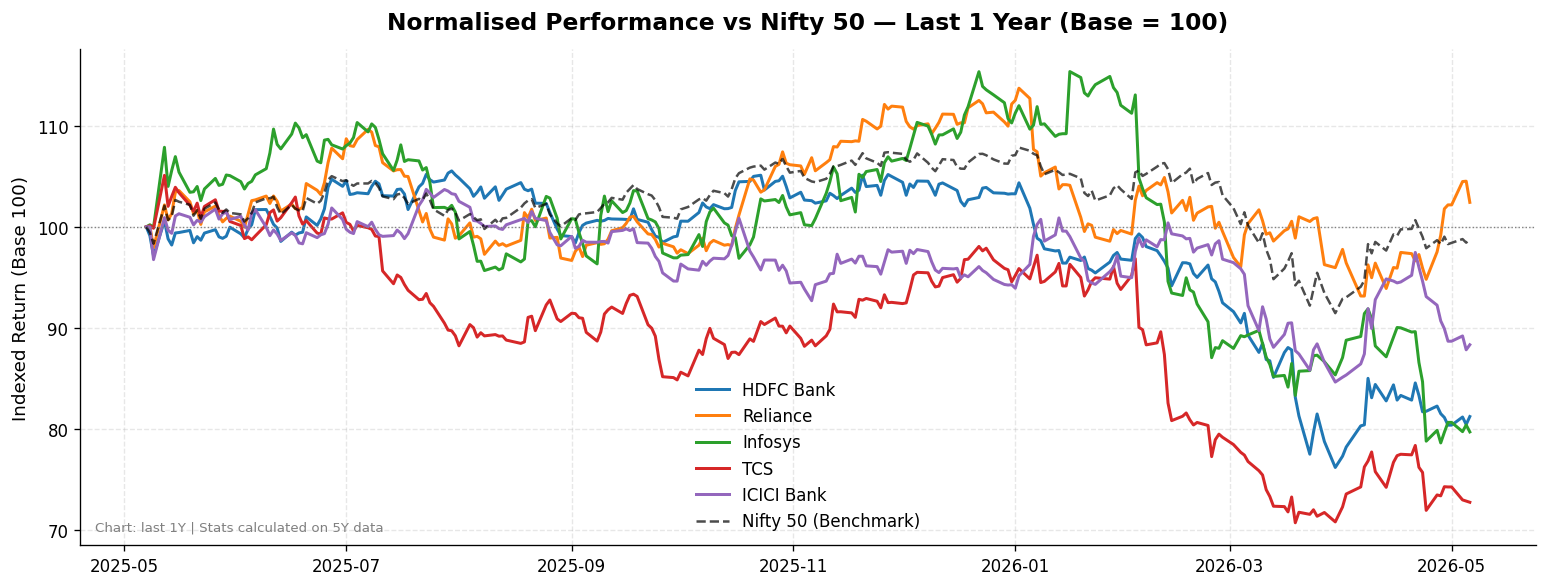

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

for stock in names:
    ax.plot(norm_1y.index, norm_1y[stock], label=stock,
            color=stock_color[stock], linewidth=1.8)

ax.plot(nifty_norm_1y.index, nifty_norm_1y,
        label='Nifty 50 (Benchmark)', color='black',
        linewidth=1.5, linestyle='--', alpha=0.7)

ax.axhline(100, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Normalised Performance vs Nifty 50 — Last 1 Year (Base = 100)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Indexed Return (Base 100)', fontsize=11)
ax.legend(frameon=False, fontsize=10)
ax.annotate('Chart: last 1Y | Stats calculated on 5Y data',
            xy=(0.01, 0.03), xycoords='axes fraction', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('normalised_performance.png', bbox_inches='tight')
plt.show()

---
## 🗓️ Section 5 — Annual Returns by Year (Regime Analysis)

> This directly addresses the single-regime limitation of 1Y analysis.  
> Each year represents a different macro environment — COVID crash (2020), rate hike cycle (2022), recovery (2023–24).

Annual Returns by Calendar Year (%)
      HDFC Bank  Reliance  Infosys   TCS  ICICI Bank  Nifty 50
Date                                                          
2022       11.3       7.9    -18.4 -11.7        21.1       4.3
2023        6.2      10.3      5.0  20.6        12.8      20.0
2024        5.1      -5.6     25.7  10.0        29.7       8.8
2025       13.3      29.7    -11.5 -19.0         5.6      10.5
2026      -21.3      -8.7    -27.7 -23.0        -6.3      -7.7

Key regimes:
  2020 — COVID crash + recovery
  2022 — Aggressive RBI rate hike cycle
  2023 — Rate pause, domestic recovery


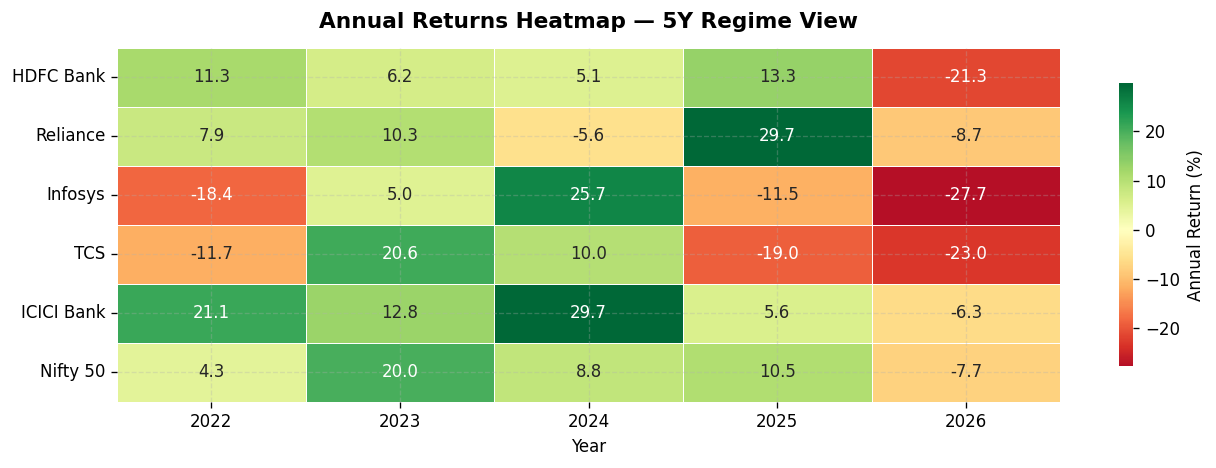

In [6]:
# Annual returns — last price of each calendar year
annual_prices  = close_5y.resample('YE').last()
annual_returns = annual_prices.pct_change().dropna() * 100
annual_returns.index = annual_returns.index.year

# Also add Nifty
nifty_annual = nifty_5y.resample('YE').last().pct_change().dropna() * 100
nifty_annual.index = nifty_annual.index.year
annual_returns['Nifty 50'] = nifty_annual

print('Annual Returns by Calendar Year (%)')
print('=' * 65)
print(annual_returns.round(1).to_string())
print()
print('Key regimes:')
print('  2020 — COVID crash + recovery')
print('  2022 — Aggressive RBI rate hike cycle')
print('  2023 — Rate pause, domestic recovery')

# Heatmap
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    annual_returns.T,
    annot=True, fmt='.1f',
    cmap='RdYlGn', center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Annual Return (%)', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Annual Returns Heatmap — 5Y Regime View', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year')
plt.tight_layout()
plt.savefig('annual_returns_heatmap.png', bbox_inches='tight')
plt.show()

---
## 🔢 Section 6 — Daily Returns & Distribution (1Y chart, 5Y stats)

Daily Returns — Descriptive Statistics (5Y basis):
            Count     Mean Std Dev      Min      25%   Median     75%      Max
HDFC Bank    1236   0.022%  1.308%  -8.436%  -0.650%   0.037%  0.692%  10.013%
Reliance     1236   0.050%  1.414%  -7.485%  -0.796%   0.062%  0.797%   7.019%
Infosys      1236   0.010%  1.551%  -9.423%  -0.848%   0.018%  0.892%   7.934%
TCS          1236  -0.001%  1.327%  -7.013%  -0.696%  -0.025%  0.693%   6.633%
ICICI Bank   1236   0.070%  1.291%  -7.634%  -0.610%   0.039%  0.712%  10.852%


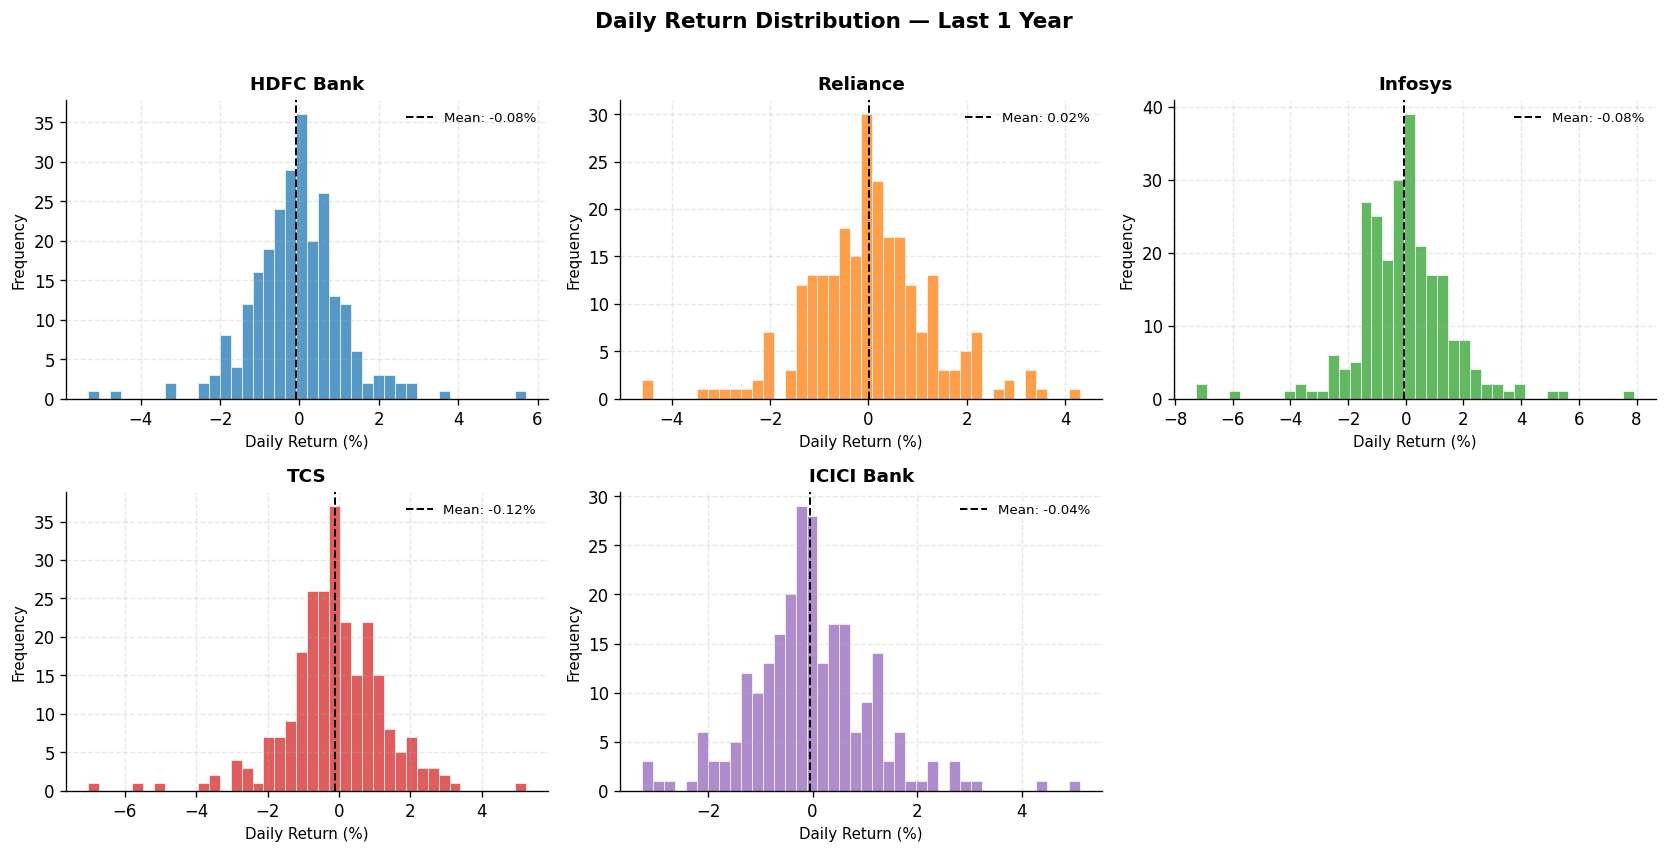

In [7]:
# Calculate returns on full 5Y (for stats) and 1Y (for histogram)
daily_returns_5y = close_5y.pct_change().dropna()
daily_returns_1y = close_1y.pct_change().dropna()

print('Daily Returns — Descriptive Statistics (5Y basis):')
print('=' * 60)
summary = daily_returns_5y.describe().T
summary.columns = ['Count', 'Mean', 'Std Dev', 'Min', '25%', 'Median', '75%', 'Max']

pct_cols = ['Mean', 'Std Dev', 'Min', '25%', 'Median', '75%', 'Max']
display_summary = summary.copy()
for col in pct_cols:
    display_summary[col] = display_summary[col].apply(lambda x: f'{x*100:.3f}%')
display_summary['Count'] = display_summary['Count'].astype(int)
print(display_summary.to_string())

# Distribution histograms — 1Y returns for recency
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, stock in enumerate(names):
    ax = axes[i]
    returns = daily_returns_1y[stock] * 100
    ax.hist(returns, bins=40, color=stock_color[stock], alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(returns.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {returns.mean():.2f}%')
    ax.set_title(stock, fontsize=11, fontweight='bold')
    ax.set_xlabel('Daily Return (%)', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8, frameon=False)

axes[5].set_visible(False)
fig.suptitle('Daily Return Distribution — Last 1 Year', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('return_distributions.png', bbox_inches='tight')
plt.show()

---
## 💹 Section 7 — Cumulative Returns (1Y chart)

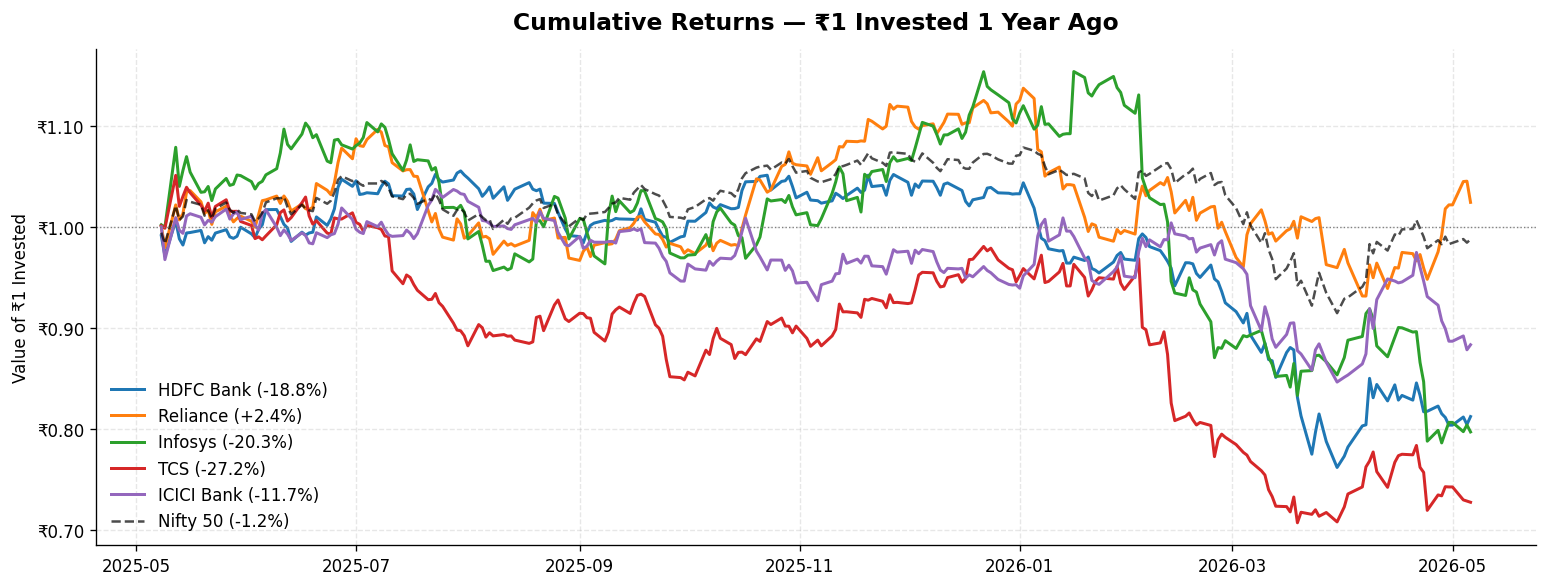

In [8]:
cum_returns_1y  = (1 + daily_returns_1y).cumprod()
nifty_daily_1y  = nifty_1y.pct_change().dropna()
nifty_cum_1y    = (1 + nifty_daily_1y).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))

for stock in names:
    final_val = cum_returns_1y[stock].iloc[-1]
    ax.plot(cum_returns_1y.index, cum_returns_1y[stock],
            label=f'{stock} ({(final_val-1)*100:+.1f}%)',
            color=stock_color[stock], linewidth=1.8)

nifty_final = nifty_cum_1y.iloc[-1]
ax.plot(nifty_cum_1y.index, nifty_cum_1y,
        label=f'Nifty 50 ({(nifty_final-1)*100:+.1f}%)',
        color='black', linewidth=1.5, linestyle='--', alpha=0.7)

ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Cumulative Returns — ₹1 Invested 1 Year Ago', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Value of ₹1 Invested')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.2f}'))
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('cumulative_returns.png', bbox_inches='tight')
plt.show()

---
## 📉 Section 8 — Volatility Analysis (5Y stats, 1Y rolling chart)

> Annualised volatility is calculated on 5Y daily returns — more statistically reliable.  
> Rolling chart shows last 1Y for readability.

Annualised Volatility — 5Y basis (%)
  HDFC Bank      20.8%  ██████████
  Reliance       22.4%  ███████████
  Infosys        24.6%  ████████████
  TCS            21.1%  ██████████
  ICICI Bank     20.5%  ██████████


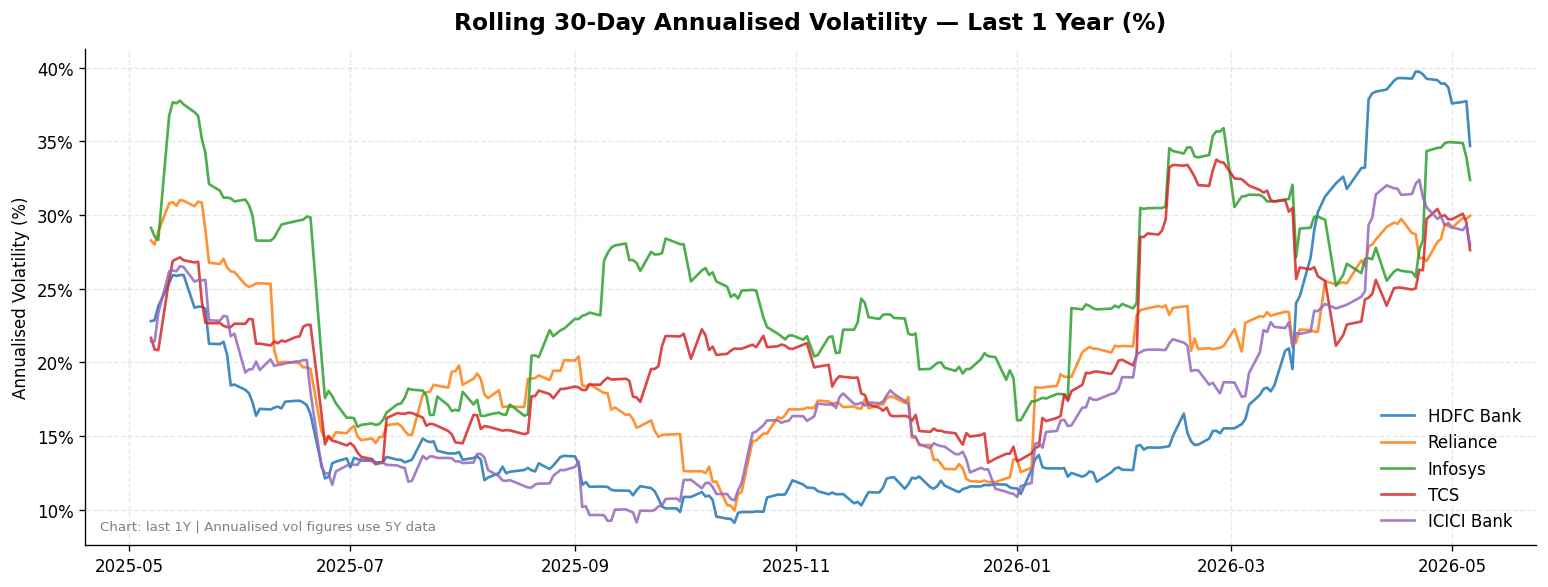

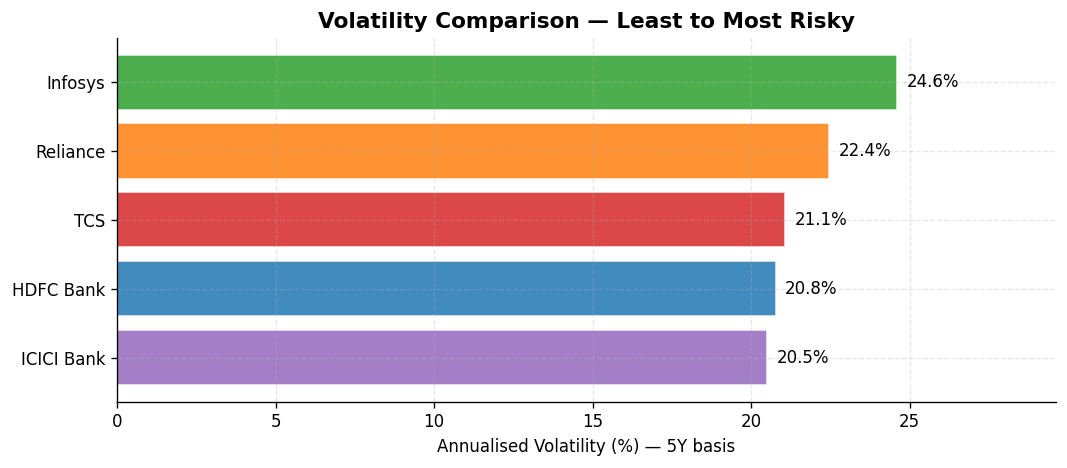

In [9]:
# Annualised volatility — calculated on 5Y
ann_volatility = daily_returns_5y.std() * np.sqrt(TRADING_DAYS) * 100

# Rolling 30-day vol — plot only 1Y window
rolling_vol_5y = daily_returns_5y.rolling(window=30).std() * np.sqrt(TRADING_DAYS) * 100
rolling_vol_1y = rolling_vol_5y.last('365D')

print('Annualised Volatility — 5Y basis (%)')
print('=' * 35)
for stock in names:
    vol = ann_volatility[stock]
    bar = '█' * int(vol / 2)
    print(f'  {stock:<12}  {vol:5.1f}%  {bar}')

# Rolling vol chart — 1Y window
fig, ax = plt.subplots(figsize=(13, 5))
for stock in names:
    ax.plot(rolling_vol_1y.index, rolling_vol_1y[stock],
            label=stock, color=stock_color[stock], linewidth=1.6, alpha=0.85)

ax.set_title('Rolling 30-Day Annualised Volatility — Last 1 Year (%)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Annualised Volatility (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(frameon=False, fontsize=10)
ax.annotate('Chart: last 1Y | Annualised vol figures use 5Y data',
            xy=(0.01, 0.03), xycoords='axes fraction', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('rolling_volatility.png', bbox_inches='tight')
plt.show()

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
sorted_vol = ann_volatility.sort_values(ascending=True)
bars = ax.barh(sorted_vol.index, sorted_vol.values,
               color=[stock_color[s] for s in sorted_vol.index],
               alpha=0.85, edgecolor='white')
for bar, val in zip(bars, sorted_vol.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Annualised Volatility (%) — 5Y basis')
ax.set_title('Volatility Comparison — Least to Most Risky', fontsize=13, fontweight='bold')
ax.set_xlim(0, sorted_vol.max() + 5)
plt.tight_layout()
plt.savefig('volatility_comparison.png', bbox_inches='tight')
plt.show()

---
## 🏦 Section 9 — MACRO OVERLAY 1: RBI Rate Decisions on Banking Stocks

> HDFC Bank and ICICI Bank are sensitive to RBI rate cycles.  
> Red dashes = rate hikes (tightening) | Green dashes = rate cuts (easing)  
> Watch how banking stocks react around these dates.

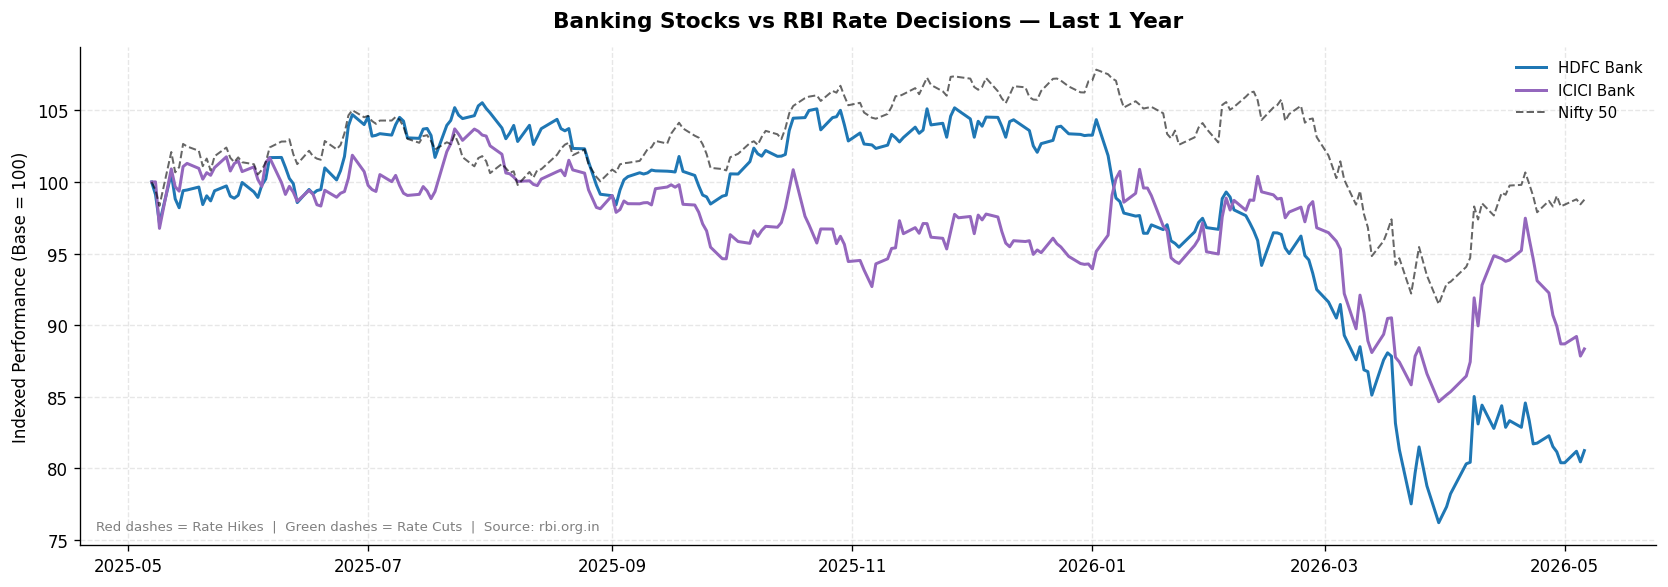

Interpretation:
  • Banking stocks typically rally when rate cuts are expected (cheaper borrowing cost)
  • They tend to underperform during aggressive hike cycles (credit growth slows)
  • Watch NIM (Net Interest Margin) — it expands on hikes short-term, then compresses


In [10]:
# RBI rate change decisions (bps) — source: rbi.org.in
rate_changes = {
    '2020-03-27': -75,   # Emergency COVID cut
    '2020-05-22': -40,   # Follow-up cut
    '2022-05-04': +40,   # Start of hike cycle
    '2022-06-08': +50,
    '2022-08-05': +50,
    '2022-09-30': +50,
    '2022-12-07': +35,
    '2023-02-08': +25,   # Final hike
    '2024-10-09': -25,   # First cut
    '2025-02-07': -25,
}

banking_stocks = ['HDFC Bank', 'ICICI Bank']

fig, ax = plt.subplots(figsize=(14, 5))

for stock in banking_stocks:
    ax.plot(norm_1y.index, norm_1y[stock],
            label=stock, color=stock_color[stock], linewidth=1.8)

ax.plot(nifty_norm_1y.index, nifty_norm_1y,
        label='Nifty 50', color='black', linewidth=1.2, linestyle='--', alpha=0.6)

ymin, ymax = ax.get_ylim()

legend_hike = legend_cut = False
for date_str, change in rate_changes.items():
    date = pd.Timestamp(date_str)
    if norm_1y.index[0] <= date <= norm_1y.index[-1]:
        c = 'red' if change > 0 else 'green'
        lbl = None
        if change > 0 and not legend_hike:
            lbl = 'RBI Rate Hike'
            legend_hike = True
        elif change < 0 and not legend_cut:
            lbl = 'RBI Rate Cut'
            legend_cut = True
        ax.axvline(date, color=c, alpha=0.45, linewidth=1.5, linestyle='--', label=lbl)
        ax.text(date, ymax * 0.97, f'{change:+}bps',
                fontsize=7, color=c, ha='center', rotation=90, va='top')

ax.set_title('Banking Stocks vs RBI Rate Decisions — Last 1 Year',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Indexed Performance (Base = 100)')
ax.legend(frameon=False, fontsize=9)
ax.annotate('Red dashes = Rate Hikes  |  Green dashes = Rate Cuts  |  Source: rbi.org.in',
            xy=(0.01, 0.03), xycoords='axes fraction', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('banking_rbi_overlay.png', bbox_inches='tight')
plt.show()

print('Interpretation:')
print('  • Banking stocks typically rally when rate cuts are expected (cheaper borrowing cost)')
print('  • They tend to underperform during aggressive hike cycles (credit growth slows)')
print('  • Watch NIM (Net Interest Margin) — it expands on hikes short-term, then compresses')

---
## 💱 Section 10 — MACRO OVERLAY 2: USD/INR Impact on IT Stocks

> Infosys and TCS earn revenues in USD but report in INR.  
> A weaker rupee inflates their INR returns — which can be misleading.  
> Dollar-adjusted return shows the *real* return for a USD-based investor.

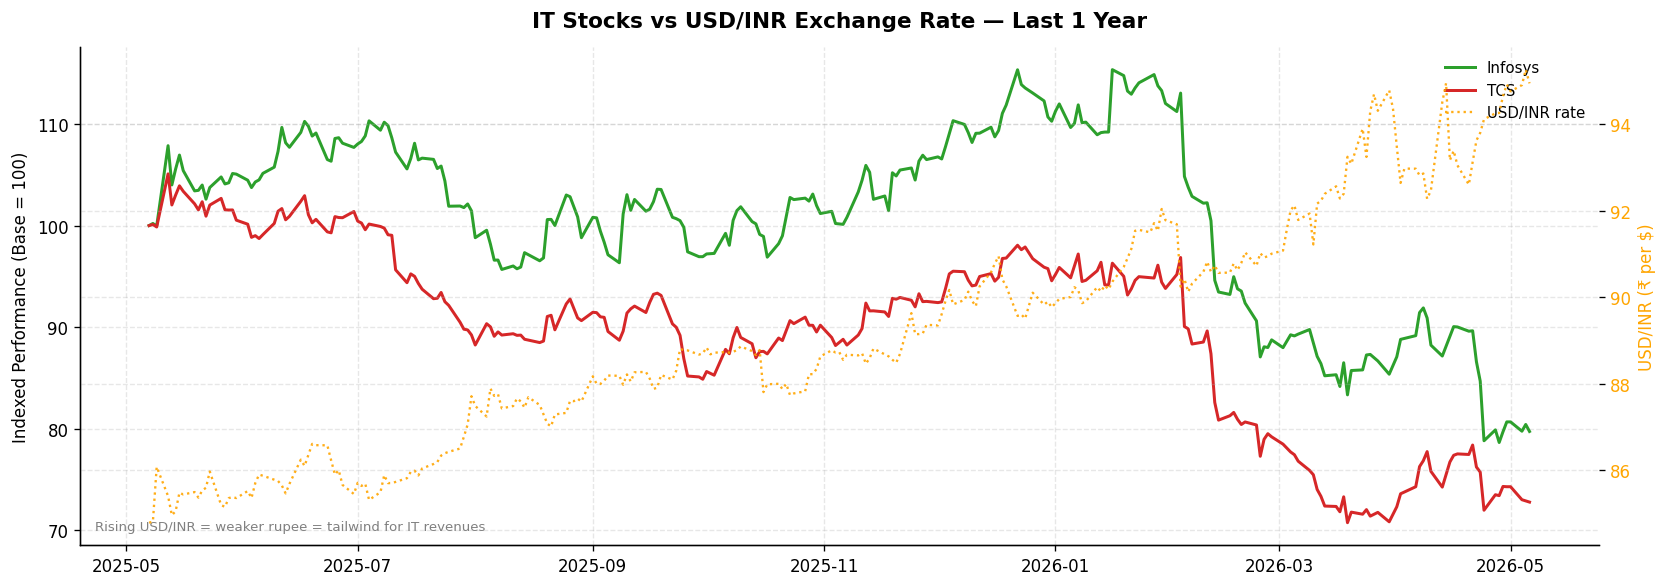

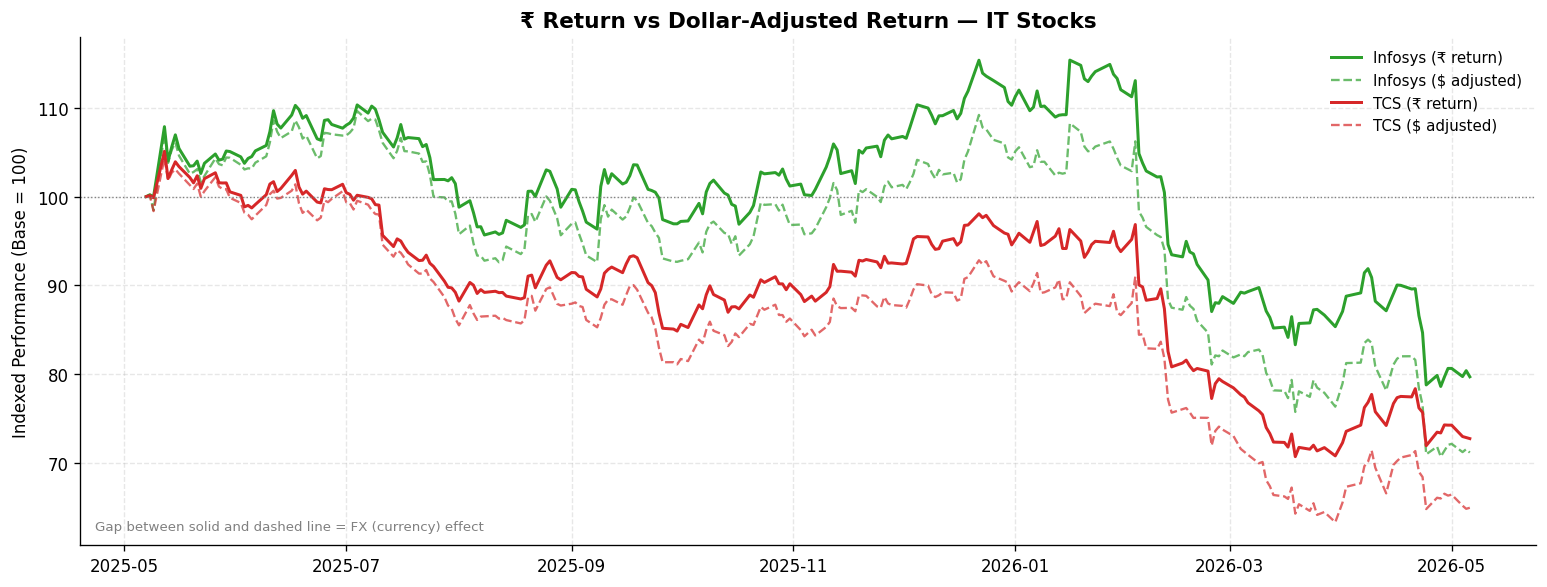

Currency Impact on IT Stock Returns (Last 1 Year):
  Infosys       ₹ return: -20.3%   $ adjusted: -28.8%   FX boost: +8.5%
  TCS           ₹ return: -27.2%   $ adjusted: -35.0%   FX boost: +7.8%

Interpretation:
  • A positive FX boost means rupee depreciation inflated the ₹ return
  • Dollar-adjusted return is what a foreign investor actually earned
  • Pure fundamental performance = $ adjusted return


In [11]:
print('Downloading USD/INR exchange rate...')
usdinr_raw = yf.download('INR=X', period=PERIOD_STATS, auto_adjust=True, progress=False)['Close']
usdinr_raw = usdinr_raw.squeeze()
usdinr_1y  = usdinr_raw.last('365D')

it_stocks = ['Infosys', 'TCS']

# ── Chart 1: IT stocks + USD/INR on dual axis ────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

for stock in it_stocks:
    ax1.plot(norm_1y.index, norm_1y[stock],
             label=stock, color=stock_color[stock], linewidth=1.8)

ax2 = ax1.twinx()
ax2.plot(usdinr_1y.index, usdinr_1y, color='orange',
         linewidth=1.4, linestyle=':', label='USD/INR rate', alpha=0.9)
ax2.set_ylabel('USD/INR (₹ per $)', color='orange', fontsize=10)
ax2.tick_params(axis='y', labelcolor='orange')

ax1.set_title('IT Stocks vs USD/INR Exchange Rate — Last 1 Year',
              fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Indexed Performance (Base = 100)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=9)
ax1.annotate('Rising USD/INR = weaker rupee = tailwind for IT revenues',
             xy=(0.01, 0.03), xycoords='axes fraction', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('it_usdinr_overlay.png', bbox_inches='tight')
plt.show()

# ── Chart 2: INR return vs dollar-adjusted return ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

usdinr_aligned = usdinr_raw.reindex(close_1y.index, method='ffill')

for stock in it_stocks:
    # Raw INR return
    raw_norm = (close_1y[stock] / close_1y[stock].iloc[0]) * 100

    # Dollar-adjusted return
    price_usd = close_1y[stock] / usdinr_aligned
    usd_norm  = (price_usd / price_usd.iloc[0]) * 100

    ax.plot(raw_norm.index, raw_norm,
            label=f'{stock} (₹ return)', color=stock_color[stock], linewidth=1.8)
    ax.plot(usd_norm.index, usd_norm,
            label=f'{stock} ($ adjusted)', color=stock_color[stock],
            linewidth=1.4, linestyle='--', alpha=0.7)

ax.axhline(100, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('₹ Return vs Dollar-Adjusted Return — IT Stocks', fontsize=13, fontweight='bold')
ax.set_ylabel('Indexed Performance (Base = 100)')
ax.legend(frameon=False, fontsize=9)
ax.annotate('Gap between solid and dashed line = FX (currency) effect',
            xy=(0.01, 0.03), xycoords='axes fraction', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('it_currency_adjusted.png', bbox_inches='tight')
plt.show()

# ── Print FX impact summary ──────────────────────────────────────────────────
print('Currency Impact on IT Stock Returns (Last 1 Year):')
print('=' * 55)
for stock in it_stocks:
    raw    = (close_1y[stock].iloc[-1] / close_1y[stock].iloc[0] - 1) * 100
    p_usd  = close_1y[stock] / usdinr_aligned
    usd_adj = (p_usd.iloc[-1] / p_usd.iloc[0] - 1) * 100
    fx     = raw - usd_adj
    print(f'  {stock:<12}  ₹ return: {raw:+.1f}%   $ adjusted: {usd_adj:+.1f}%   FX boost: {fx:+.1f}%')
print()
print('Interpretation:')
print('  • A positive FX boost means rupee depreciation inflated the ₹ return')
print('  • Dollar-adjusted return is what a foreign investor actually earned')
print('  • Pure fundamental performance = $ adjusted return')

---
## 🔗 Section 11 — Correlation Matrix (5Y basis)

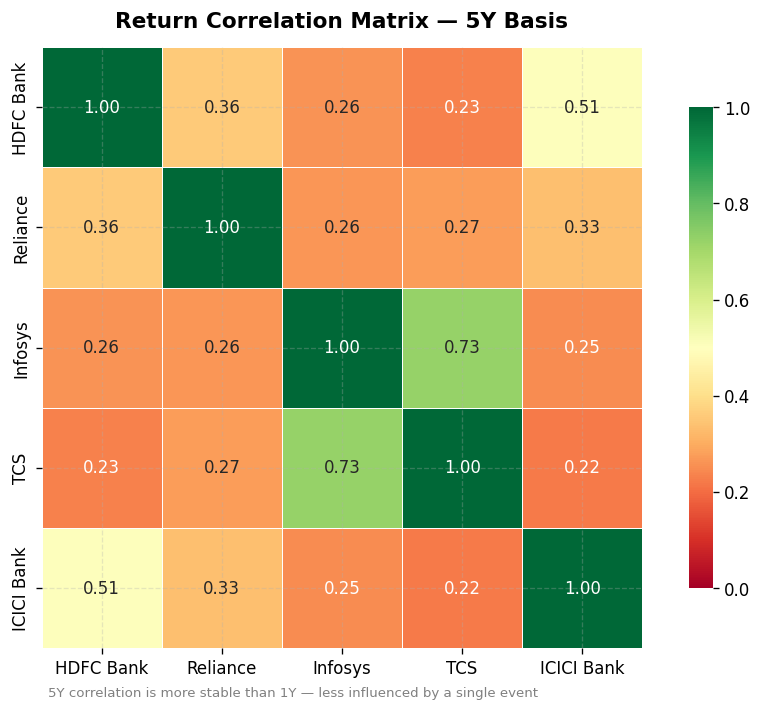

Key insight: HDFC Bank & ICICI Bank typically show high correlation (~0.7+)
             IT stocks (TCS, Infosys) also move together
             Reliance usually has lowest correlation with IT — best diversifier


In [12]:
corr_matrix = daily_returns_5y.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=0, vmax=1,
    center=0.5,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Return Correlation Matrix — 5Y Basis', fontsize=13, fontweight='bold', pad=12)
ax.annotate('5Y correlation is more stable than 1Y — less influenced by a single event',
            xy=(0.01, -0.08), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

print('Key insight: HDFC Bank & ICICI Bank typically show high correlation (~0.7+)')
print('             IT stocks (TCS, Infosys) also move together')
print('             Reliance usually has lowest correlation with IT — best diversifier')

---
## 🏆 Section 12 — Summary Dashboard (5Y Stats, Investment-Ready)

In [13]:
summary_data = {}

for stock in names:
    prices_5y = close_5y[stock].dropna()
    prices_1y = close_1y[stock].dropna()
    rets_5y   = daily_returns_5y[stock].dropna()
    rets_1y   = daily_returns_1y[stock].dropna()

    total_return_1y = (prices_1y.iloc[-1] / prices_1y.iloc[0] - 1) * 100
    total_return_5y = (prices_5y.iloc[-1] / prices_5y.iloc[0] - 1) * 100

    ann_vol_pct   = rets_5y.std() * np.sqrt(TRADING_DAYS) * 100
    ann_ret_pct   = rets_5y.mean() * TRADING_DAYS * 100
    sharpe        = (ann_ret_pct / ann_vol_pct) if ann_vol_pct != 0 else 0

    # Max drawdown — over 5Y
    rolling_max   = prices_5y.cummax()
    drawdown_ser  = (prices_5y / rolling_max - 1) * 100
    max_drawdown  = drawdown_ser.min()
    curr_drawdown = (prices_5y.iloc[-1] / prices_5y.max() - 1) * 100

    best_day  = rets_1y.max() * 100
    worst_day = rets_1y.min() * 100
    pos_days  = (rets_1y > 0).sum() / len(rets_1y) * 100

    summary_data[stock] = {
        'Start Price (₹)':        f'{prices_1y.iloc[0]:,.1f}',
        'End Price (₹)':          f'{prices_1y.iloc[-1]:,.1f}',
        '1Y Total Return':        f'{total_return_1y:+.1f}%',
        '5Y Total Return':        f'{total_return_5y:+.1f}%',
        'Ann. Volatility (5Y)':   f'{ann_vol_pct:.1f}%',
        'Sharpe Ratio (5Y)*':     f'{sharpe:.2f}',
        'Max Drawdown (5Y)':      f'{max_drawdown:.1f}%',
        'Curr. Drawdown from Peak': f'{curr_drawdown:.1f}%',
        'Best Day (1Y)':          f'{best_day:+.2f}%',
        'Worst Day (1Y)':         f'{worst_day:+.2f}%',
        '% Positive Days (1Y)':   f'{pos_days:.0f}%',
    }

summary_df = pd.DataFrame(summary_data)

print('=' * 70)
print('       EQUITY ANALYSIS SUMMARY — 5 NIFTY STOCKS')
print('       Stats: 5Y basis | Chart metrics: 1Y basis')
print('=' * 70)
print(summary_df.to_string())
print('=' * 70)
print('* Sharpe = Ann. Return / Ann. Volatility (risk-free rate = 0)')

# Rankings
ret_rank  = sorted(names, key=lambda s: float(summary_data[s]['1Y Total Return'].replace('%','').replace('+','')), reverse=True)
vol_rank  = sorted(names, key=lambda s: float(summary_data[s]['Ann. Volatility (5Y)'].replace('%','')), reverse=False)
shrp_rank = sorted(names, key=lambda s: float(summary_data[s]['Sharpe Ratio (5Y)*']), reverse=True)
dd_rank   = sorted(names, key=lambda s: float(summary_data[s]['Max Drawdown (5Y)'].replace('%','')), reverse=True)

print()
print('📊 RANKINGS')
print('─' * 45)
print('🏆 Best 1Y Return:          ', ret_rank[0])
print('📉 Lowest 5Y Volatility:    ', vol_rank[0])
print('⚡ Best 5Y Sharpe Ratio:    ', shrp_rank[0])
print('🛡️  Smallest Max Drawdown:   ', dd_rank[0])
print()
print('Return ranking (best → worst):     ', ' > '.join(ret_rank))
print('Risk ranking   (lowest → highest): ', ' > '.join(vol_rank))
print('Sharpe ranking (best → worst):     ', ' > '.join(shrp_rank))

       EQUITY ANALYSIS SUMMARY — 5 NIFTY STOCKS
       Stats: 5Y basis | Chart metrics: 1Y basis
                         HDFC Bank Reliance  Infosys      TCS ICICI Bank
Start Price (₹)              959.8  1,400.4  1,464.9  3,330.0    1,424.4
End Price (₹)                779.8  1,434.3  1,168.0  2,423.5    1,258.4
1Y Total Return             -18.8%    +2.4%   -20.3%   -27.2%     -11.7%
5Y Total Return             +17.5%   +63.8%    -2.6%   -11.4%    +113.9%
Ann. Volatility (5Y)         20.8%    22.4%    24.6%    21.1%      20.5%
Sharpe Ratio (5Y)*            0.26     0.56     0.10    -0.01       0.86
Max Drawdown (5Y)           -27.8%   -27.2%   -40.7%   -45.4%     -22.3%
Curr. Drawdown from Peak    -23.0%    -9.9%   -39.9%   -43.8%     -14.8%
Best Day (1Y)               +5.71%   +4.31%   +7.91%   +5.23%     +5.11%
Worst Day (1Y)              -5.32%   -4.60%   -7.26%   -7.01%     -3.26%
% Positive Days (1Y)           46%      50%      48%      44%        44%
* Sharpe = Ann. Return / An

---
## 📋 Section 13 — Key Concepts Reference

| Metric | Formula | Basis | What it tells you |
|--------|---------|-------|-------------------|
| **Daily Return** | (P_t − P_{t-1}) / P_{t-1} | Daily | % gain/loss each trading day |
| **1Y Total Return** | (End / Start) − 1 | 1Y | Recent performance |
| **5Y Total Return** | (End / Start) − 1 | 5Y | Full cycle performance |
| **Annualised Volatility** | σ_daily × √252 | 5Y | Risk — how much returns fluctuate per year |
| **Sharpe Ratio** | Ann. Return / Ann. Volatility | 5Y | Return per unit of risk |
| **Max Drawdown** | Worst peak-to-trough drop | 5Y | Worst-case loss scenario |
| **Correlation** | Pearson r between return series | 5Y | How similarly two stocks move |
| **Dollar-Adjusted Return** | ₹ return stripped of FX | 1Y | Real return ex-currency effect |

---

## 🔜 What's Next — Week 2 Builds On This:
- **Beta vs Nifty** — CAPM market sensitivity
- **Momentum Screener** — rank stocks by 1M/3M/6M returns
- **Factor Regression** — decompose returns into market/sector/stock-specific alpha

---
*Notebook v2 — built during Motilal Oswal SIP 2026 | Kishore*